In [16]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [17]:
df = pd.read_csv("housing.csv")

In [18]:
df['income_cat'] = pd.cut(df['median_income'], bins=[0,1.5,3.0,4.5,6.0, np.inf], labels=[1,2,3,4,5])

Text(0.5, 0, 'Income Category')

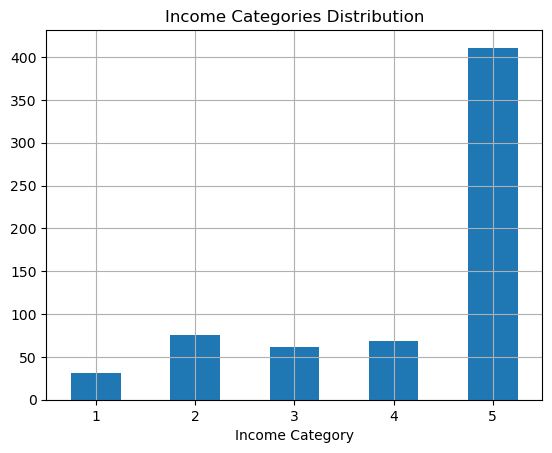

In [19]:
import matplotlib.pyplot as plt
df["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.title("Income Categories Distribution")
plt.xlabel("Income Category")

In [20]:
# x=df[['longitude', 'latitude', 'housing_median_age', 'total_rooms',
#        'total_bedrooms', 'population', 'households', 'median_income']]
# y=df['median_house_value']


In [21]:
df = df.ffill()

In [22]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-120.5673,34.2588,28.0,3896.0,3925.0,6461.0,44.0,14.1670,254580.0,NEAR OCEAN,5
1,-114.5175,37.6481,7.0,334.0,1660.0,6415.0,4958.0,14.3397,180334.0,NEAR OCEAN,5
2,-116.8141,40.7930,35.0,9220.0,2973.0,15499.0,2858.0,4.3507,413581.0,<1H OCEAN,3
3,-118.2141,39.4561,28.0,3707.0,3932.0,742.0,757.0,9.7376,493833.0,NEAR BAY,5
4,-122.8618,40.1623,14.0,8143.0,3271.0,1528.0,199.0,7.6371,461811.0,NEAR OCEAN,5
...,...,...,...,...,...,...,...,...,...,...,...
644,-123.2425,33.3467,48.0,341.0,4369.0,11925.0,5191.0,1.3303,255704.0,INLAND,1
645,-115.1495,39.6751,12.0,2768.0,833.0,17019.0,5428.0,6.7923,319580.0,<1H OCEAN,5
646,-118.2673,33.7133,38.0,902.0,999.0,5873.0,3881.0,5.1895,398857.0,NEAR OCEAN,4
647,-117.3694,40.3476,1.0,5159.0,3989.0,12012.0,5765.0,11.4735,469970.0,INLAND,5


In [23]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-120.5673,34.2588,28.0,3896.0,3925.0,6461.0,44.0,14.1670,254580.0,NEAR OCEAN,5
1,-114.5175,37.6481,7.0,334.0,1660.0,6415.0,4958.0,14.3397,180334.0,NEAR OCEAN,5
2,-116.8141,40.7930,35.0,9220.0,2973.0,15499.0,2858.0,4.3507,413581.0,<1H OCEAN,3
3,-118.2141,39.4561,28.0,3707.0,3932.0,742.0,757.0,9.7376,493833.0,NEAR BAY,5
4,-122.8618,40.1623,14.0,8143.0,3271.0,1528.0,199.0,7.6371,461811.0,NEAR OCEAN,5
...,...,...,...,...,...,...,...,...,...,...,...
644,-123.2425,33.3467,48.0,341.0,4369.0,11925.0,5191.0,1.3303,255704.0,INLAND,1
645,-115.1495,39.6751,12.0,2768.0,833.0,17019.0,5428.0,6.7923,319580.0,<1H OCEAN,5
646,-118.2673,33.7133,38.0,902.0,999.0,5873.0,3881.0,5.1895,398857.0,NEAR OCEAN,4
647,-117.3694,40.3476,1.0,5159.0,3989.0,12012.0,5765.0,11.4735,469970.0,INLAND,5


In [24]:
df.drop(columns=["ocean_proximity"],inplace=True)

In [25]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,income_cat
0,-120.5673,34.2588,28.0,3896.0,3925.0,6461.0,44.0,14.1670,254580.0,5
1,-114.5175,37.6481,7.0,334.0,1660.0,6415.0,4958.0,14.3397,180334.0,5
2,-116.8141,40.7930,35.0,9220.0,2973.0,15499.0,2858.0,4.3507,413581.0,3
3,-118.2141,39.4561,28.0,3707.0,3932.0,742.0,757.0,9.7376,493833.0,5
4,-122.8618,40.1623,14.0,8143.0,3271.0,1528.0,199.0,7.6371,461811.0,5
...,...,...,...,...,...,...,...,...,...,...
644,-123.2425,33.3467,48.0,341.0,4369.0,11925.0,5191.0,1.3303,255704.0,1
645,-115.1495,39.6751,12.0,2768.0,833.0,17019.0,5428.0,6.7923,319580.0,5
646,-118.2673,33.7133,38.0,902.0,999.0,5873.0,3881.0,5.1895,398857.0,4
647,-117.3694,40.3476,1.0,5159.0,3989.0,12012.0,5765.0,11.4735,469970.0,5


In [26]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,-119.283596,37.368688,26.195686,4948.731895,2566.015408,9865.733436,3083.143297,7.930068,267913.984592
std,3.117050,2.789261,14.689069,2788.794657,1435.944563,5793.936601,1756.577422,4.137836,127846.316873
min,-124.446900,32.546900,1.000000,118.000000,66.000000,110.000000,24.000000,1.008800,50801.000000
25%,-121.984600,34.768400,14.000000,2635.000000,1302.000000,5083.000000,1487.000000,4.324800,158241.000000
50%,-119.160000,37.569200,26.000000,4691.000000,2561.000000,9549.000000,3169.000000,8.016300,260503.000000
75%,-116.571100,39.741700,39.000000,7452.000000,3847.000000,15048.000000,4587.000000,11.280900,375438.000000
max,-114.003000,41.994400,51.000000,9989.000000,4997.000000,19994.000000,5992.000000,14.997900,497127.000000


In [27]:
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'income_cat'],
      dtype='object')


In [28]:
#import matplotlib.pyplot as plt

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

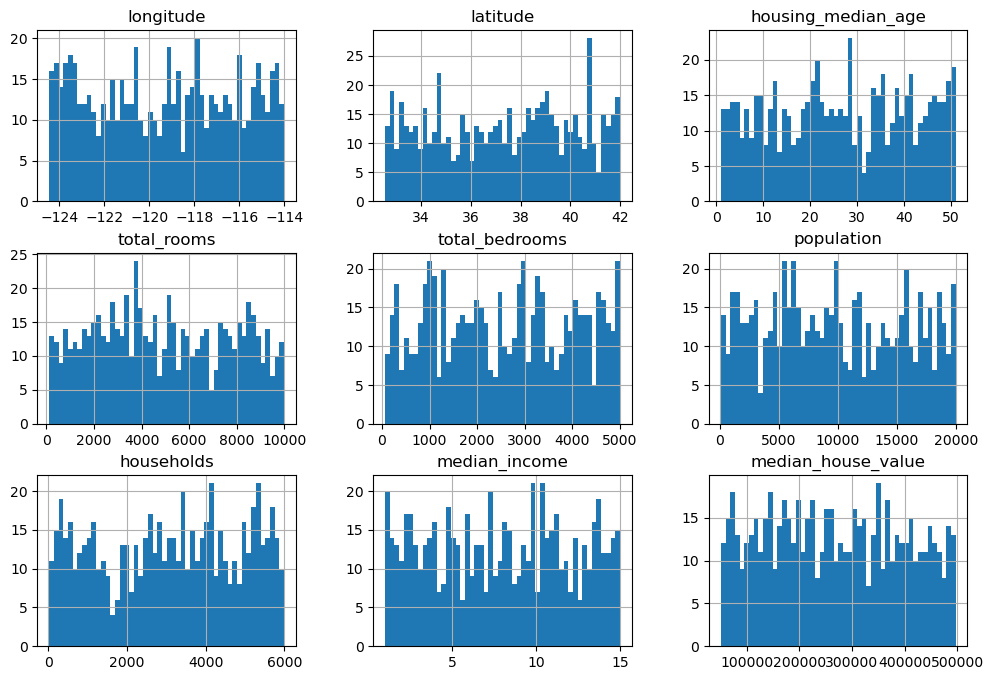

In [29]:
df.hist(bins=50,figsize=(12,8))

In [30]:
import numpy as np

In [31]:
def shuffle_and_split(data, test_ratio):
 np.random.seed(42)
 shuffled_indices = np.random.permutation(len(data))
 test_set_size = int(len(data)*test_ratio)
 test_indices = shuffled_indices[:test_set_size]
 train_indices = shuffled_indices[test_set_size:]
 return data.iloc[train_indices], data.iloc[test_indices]

In [32]:
shuffle_and_split(df,0.4)

(     longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
 431  -116.5041   37.3982                41.0       3193.0          1133.0   
 404  -121.1395   38.8061                41.0       4869.0          4167.0   
 46   -121.2270   34.7131                 3.0       6569.0          4381.0   
 261  -114.1044   40.0768                15.0       3799.0          1079.0   
 195  -120.8333   40.7796                 1.0       2995.0           920.0   
 ..         ...       ...                 ...          ...             ...   
 71   -122.4135   34.7193                39.0       2258.0          4176.0   
 106  -120.1910   36.2643                21.0       4652.0           496.0   
 270  -116.0017   39.1023                40.0       7523.0          3339.0   
 435  -117.1398   32.7847                38.0       3377.0          1035.0   
 102  -121.1993   40.8960                51.0       1072.0          2490.0   
 
      population  households  median_income  median_house_valu

In [33]:
import numpy as np
def shuffle_and_split_data(data, test_ratio):
 np.random.seed(42) # Set the seed for reproducibility
 shuffled_indices = np.random.permutation(len(data))
 test_set_size = int(len(data) * test_ratio)
 test_indices = shuffled_indices[:test_set_size]
 train_indices = shuffled_indices[test_set_size:]
 return data.iloc[train_indices], data.iloc[test_indices]

In [34]:
train, test = shuffle_and_split(df, 0.4)

In [35]:
test.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,income_cat
636,-118.9075,36.2935,27.0,7652.0,4209.0,14310.0,4115.0,13.8625,367798.0,5
220,-117.5951,41.5332,38.0,2317.0,1554.0,18374.0,2266.0,8.5106,117853.0,5
594,-115.0837,39.3812,35.0,1114.0,288.0,11511.0,2760.0,14.3703,213944.0,5
429,-123.2708,40.7452,34.0,551.0,1065.0,17769.0,438.0,3.7862,454377.0,3
72,-124.4420,32.8999,22.0,2761.0,4156.0,8721.0,1151.0,6.4641,259417.0,5


In [36]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2,random_state=42)
for train_index, test_index in split.split(df,df['income_cat']):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

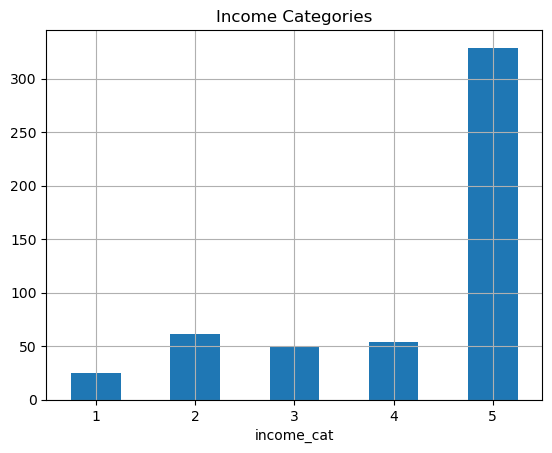

In [38]:
import matplotlib.pyplot as plt

strat_train_set["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)

plt.title("Income Categories")
plt.show()